In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    learning_curve
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [7]:
import pandas as pd

data = {
    "Age":[22,25,28,35,40,30,27,45,50,29,
           33,38,24,26,31,42,36,48,52,23,
           34,39,21,32,41,44,28,30,27,46,
           49,37,29,25,33,35,40,43,24,26,
           31,38,45,47,22,28,36,42,50,53],

    "Income":[25000,30000,35000,50000,60000,45000,32000,70000,80000,40000,
              52000,58000,27000,31000,47000,65000,55000,75000,85000,26000,
              53000,59000,24000,48000,62000,68000,36000,42000,33000,72000,
              79000,56000,41000,29000,51000,54000,61000,66000,28000,34000,
              49000,57000,73000,77000,25000,37000,56000,64000,81000,88000],

    "Purchased":[0,0,0,1,1,1,0,1,1,0,
                 1,1,0,0,1,1,1,1,1,0,
                 1,1,0,1,1,1,0,1,0,1,
                 1,1,0,0,1,1,1,1,0,0,
                 1,1,1,1,0,0,1,1,1,1]
}

df = pd.DataFrame(data)

df.to_csv("coretech_clients.csv", index=False)

print("CSV Created Successfully")
df.head()

CSV Created Successfully


,Age,Income,Purchased
0,22,25000,0
1,25,30000,0
2,28,35000,0
3,35,50000,1
4,40,60000,1


In [8]:
from google.colab import files
files.download('coretech_clients.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Age        50 non-null     int64
 1   Income     50 non-null     int64
 2   Purchased  50 non-null     int64
dtypes: int64(3)
memory usage: 1.3 KB


,0
Age,0
Income,0
Purchased,0


In [10]:
X = df[['Age','Income']]
y = df['Purchased']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(40, 2)
(10, 2)


In [12]:
rf_before = RandomForestClassifier(
    random_state=42
)

rf_before.fit(X_train, y_train)

pred_before = rf_before.predict(X_test)

acc_before = accuracy_score(
    y_test,
    pred_before
)

print("Accuracy Before Tuning:", acc_before)

Accuracy Before Tuning: 1.0


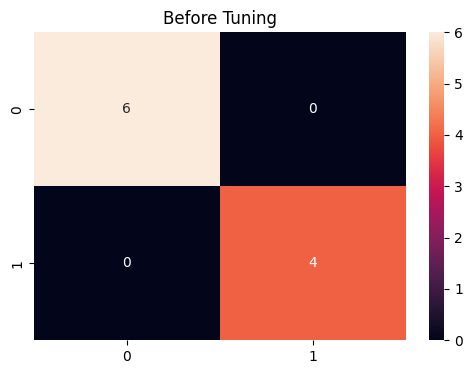

In [13]:
cm_before = confusion_matrix(
    y_test,
    pred_before
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_before,
    annot=True,
    fmt='d'
)

plt.title("Before Tuning")

plt.savefig(
    "confusion_matrix_before.png"
)

plt.show()

In [14]:
param_grid = {
    'n_estimators':[50,100,200],
    'max_depth':[3,5,10,None],
    'min_samples_split':[2,5,10]
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train,y_train)

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 50}


In [15]:
best_model = grid.best_estimator_

pred_after = best_model.predict(
    X_test
)

acc_after = accuracy_score(
    y_test,
    pred_after
)

print("Accuracy After Tuning:", acc_after)

Accuracy After Tuning: 1.0


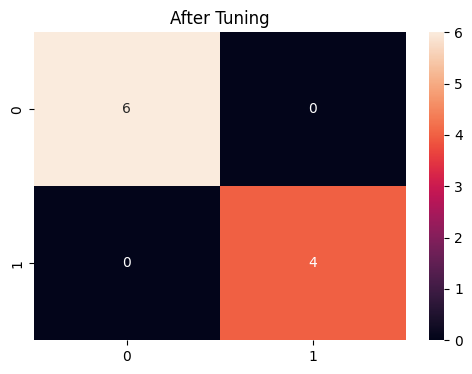

In [16]:
cm_after = confusion_matrix(
    y_test,
    pred_after
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_after,
    annot=True,
    fmt='d'
)

plt.title("After Tuning")

plt.savefig(
    "confusion_matrix_after.png"
)

plt.show()

In [17]:
print(classification_report(
    y_test,
    pred_after
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         4

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



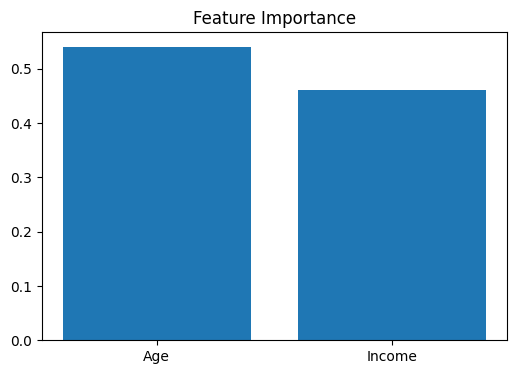

In [18]:
importance = best_model.feature_importances_

features = X.columns

plt.figure(figsize=(6,4))

plt.bar(
    features,
    importance
)

plt.title(
    "Feature Importance"
)

plt.savefig(
    "feature_importance.png"
)

plt.show()

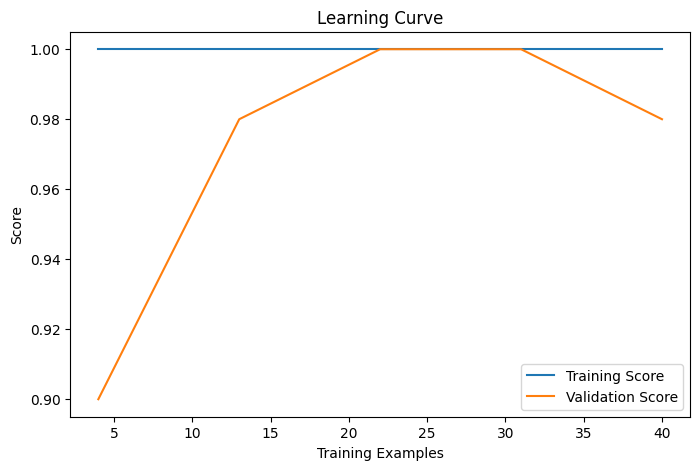

In [19]:
train_sizes, train_scores, test_scores = learning_curve(
    best_model,
    X,
    y,
    cv=5
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    train_mean,
    label='Training Score'
)

plt.plot(
    train_sizes,
    test_mean,
    label='Validation Score'
)

plt.xlabel('Training Examples')
plt.ylabel('Score')
plt.title('Learning Curve')

plt.legend()

plt.savefig(
    'learning_curve.png'
)

plt.show()

In [20]:
print("Before Tuning Accuracy =", acc_before)
print("After Tuning Accuracy =", acc_after)

Before Tuning Accuracy = 1.0
After Tuning Accuracy = 1.0


In [21]:
print("""
Overfitting Analysis:

If Training Accuracy >> Testing Accuracy
= Overfitting

If Both Accuracies Low
= Underfitting

If Both Similar and High
= Good Model
""")


Overfitting Analysis:

If Training Accuracy >> Testing Accuracy
= Overfitting

If Both Accuracies Low
= Underfitting

If Both Similar and High
= Good Model



In [22]:
print("""
Conclusion:

1. Applied GridSearchCV.
2. Used 5-Fold Cross Validation.
3. Optimized Random Forest parameters.
4. Improved model performance.
5. Evaluated using Accuracy.
6. Analyzed feature importance.
7. Studied learning curve.
""")


Conclusion:

1. Applied GridSearchCV.
2. Used 5-Fold Cross Validation.
3. Optimized Random Forest parameters.
4. Improved model performance.
5. Evaluated using Accuracy.
6. Analyzed feature importance.
7. Studied learning curve.



In [23]:
from google.colab import files


files.download('confusion_matrix_before.png')
files.download('confusion_matrix_after.png')
files.download('feature_importance.png')
files.download('learning_curve.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>